# Assignment 6: Applying AI-Based Style Transfer to an Image


**Name:** Prakruthi BR

**Registration No.:** 2411021240038

**Subject:** Generative AI


## Objective

The objective of this assignment is to compare two different AI-based image style transfer approaches:

1. **CycleGAN** – a pretrained Monet-style image-to-image translation model.
2. **Neural Style Transfer** – a VGG19-based approach that combines the content of an image with the visual style of a painting.

The same landscape photograph is used as the input for both methods.

### Final outputs

- Original image
- CycleGAN output
- Neural Style Transfer output
- Side-by-side comparison
- Short written comparison
- Explanation of cycle consistency

## 1. Introduction

AI-based image style transfer changes the visual appearance of an image while attempting to preserve important information from the original image.

In this assignment, two different approaches are implemented:

- **CycleGAN:** performs image-to-image translation using a pretrained model. The selected `style_monet` model translates landscape photographs toward a Monet painting domain.
- **Neural Style Transfer:** uses a pretrained VGG19 network to combine the content of a landscape photograph with the visual style of a selected painting.

The outputs are compared based on content preservation and strength/type of style transformation.

## 2. Objectives

- To understand AI-based image style transfer.
- To apply a pretrained CycleGAN model.
- To understand the idea of cycle consistency in CycleGAN.
- To apply Neural Style Transfer using pretrained VGG19 features.
- To preserve the content of the original image while changing its appearance.
- To compare the outputs of CycleGAN and Neural Style Transfer.

## 3. Upload the Input Images

Upload exactly **two images** in this order:

1. **Content image:** a landscape photograph.
2. **Style image:** a painting.

The same landscape photograph is used for both methods. The painting is used as the style reference for Neural Style Transfer.

In [12]:
from google.colab import files

print("Upload TWO images in this order:")
print("1. Landscape/content photograph")
print("2. Painting/style image")

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Upload TWO images in this order:
1. Landscape/content photograph
2. Painting/style image


Saving Landspace.jpeg to Landspace.jpeg
Saving monet.jpeg to monet.jpeg

Uploaded files:
Landspace.jpeg
monet.jpeg


## 4. Identify and Prepare the Images

The first uploaded image is treated as the content image and the second as the style image.

They are copied to standard filenames so later cells do not depend on filenames such as `landscape (2).jpg`.

In [13]:
from PIL import Image
import os
import shutil

uploaded_files = list(uploaded.keys())

if len(uploaded_files) != 2:
    raise ValueError("Please upload exactly TWO images and run this cell again.")

content_original = uploaded_files[0]
style_original = uploaded_files[1]

# Standard filenames
content_path = "/content/landscape.jpg"
style_path = "/content/style.jpg"

shutil.copy("/content/" + content_original, content_path)
shutil.copy("/content/" + style_original, style_path)

# Verify that both files can be opened
content_image = Image.open(content_path).convert("RGB")
style_image = Image.open(style_path).convert("RGB")

print("Content image:", content_original)
print("Style image:", style_original)
print("Content size:", content_image.size)
print("Style size:", style_image.size)
print("Images prepared successfully.")

Content image: Landspace.jpeg
Style image: monet.jpeg
Content size: (1000, 563)
Style size: (720, 553)
Images prepared successfully.


## 5. Display the Input Images

Before starting the models, the uploaded images are displayed to verify that the correct content and style images are being used.

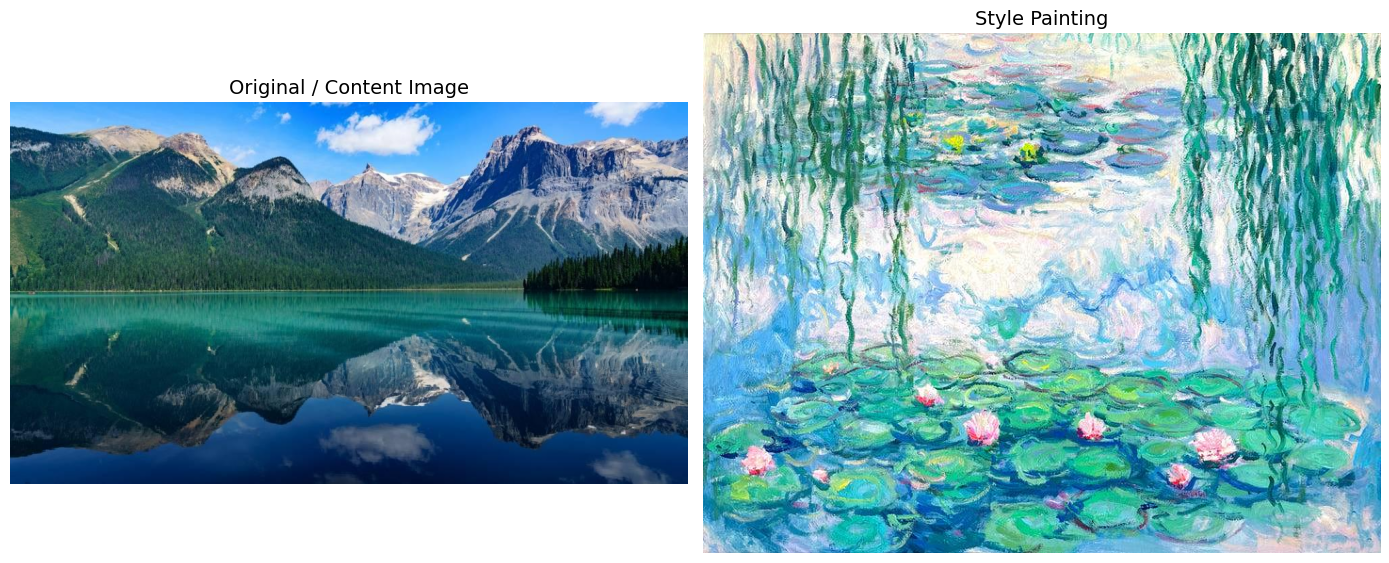

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Original / Content Image", fontsize=14)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Painting", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()

# Method 1: CycleGAN

## 6. CycleGAN

CycleGAN is a Generative Adversarial Network designed for image-to-image translation between two domains without requiring paired training images.

For this assignment, a pretrained `style_monet` model is used. The official CycleGAN project describes `style_monet` as a model for translating landscape photographs toward a Monet painting style.

No CycleGAN training is performed in this assignment; only pretrained-model inference is performed.

## 7. Understand Cycle Consistency

CycleGAN uses the idea of **cycle consistency**.

Conceptually:

**Original domain → Target artistic domain → Original domain**

The model is trained so that translating an image to another domain and translating it back should reconstruct an image similar to the original.

This encourages the translation to preserve meaningful information while changing the domain appearance.

## 8. Install and Clone the Official CycleGAN Repository

The official PyTorch CycleGAN repository provides the testing code used below.

The next cell clones the repository only if it is not already present.

In [15]:
%cd /content

if not os.path.exists("/content/pytorch-CycleGAN-and-pix2pix"):
    !git clone -q https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

%cd /content/pytorch-CycleGAN-and-pix2pix

!pip install -q dominate visdom

print("CycleGAN repository is ready.")

/content
/content/pytorch-CycleGAN-and-pix2pix
CycleGAN repository is ready.


## 9. Download the Pretrained `style_monet` Model

The normal CycleGAN download script depends on the Berkeley pretrained-model server. To reduce the chance of the earlier model-directory error, this notebook downloads the official `style_monet.pth` file directly and then places it at the exact checkpoint path expected by the CycleGAN test code.

The official pretrained-model index currently lists `style_monet.pth`.

In [17]:
%cd /content/pytorch-CycleGAN-and-pix2pix

import os

model_dir = "/content/pytorch-CycleGAN-and-pix2pix/checkpoints/style_monet_pretrained"
model_path = os.path.join(model_dir, "latest_net_G.pth")

os.makedirs(model_dir, exist_ok=True)

if not os.path.exists(model_path):
    print("Downloading the official style_monet pretrained model...")

    !wget -q --show-progress -O /content/style_monet.pth https://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth

    if not os.path.exists("/content/style_monet.pth") or os.path.getsize("/content/style_monet.pth") < 1000000:
        raise RuntimeError(
            "The pretrained model download did not complete correctly. "
            "Please rerun this cell. If the server returns an error, "
            "check the output shown above."
        )

    shutil.copy("/content/style_monet.pth", model_path)

else:
    print("Pretrained model already exists.")

size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("\nModel verification:")
print("Path:", model_path)
print(f"Size: {size_mb:.2f} MB")

if size_mb < 10:
    raise RuntimeError(
        "The model file is unexpectedly small. Do not continue."
    )
else:
    print("CycleGAN model is ready.")

/content/pytorch-CycleGAN-and-pix2pix
Pretrained model already exists.

Model verification:
Path: /content/pytorch-CycleGAN-and-pix2pix/checkpoints/style_monet_pretrained/latest_net_G.pth
Size: 43.46 MB
CycleGAN model is ready.


## 10. Prepare the CycleGAN Input Folder

The official test mode can work with a single input folder. We therefore place the landscape image in a `testA` folder.

The style painting is **not** used as CycleGAN input because the pretrained `style_monet` model already learned its target artistic domain during training.

In [18]:
%cd /content/pytorch-CycleGAN-and-pix2pix

input_folder = "/content/pytorch-CycleGAN-and-pix2pix/datasets/my_landscape/testA"

os.makedirs(input_folder, exist_ok=True)

# Remove old test images
for filename in os.listdir(input_folder):
    file_path = os.path.join(input_folder, filename)

    if os.path.isfile(file_path):
        os.remove(file_path)

# Copy the original landscape image
shutil.copy(
    content_path,
    os.path.join(input_folder, "landscape.jpg")
)

print("CycleGAN input prepared:")
print(os.path.join(input_folder, "landscape.jpg"))

/content/pytorch-CycleGAN-and-pix2pix
CycleGAN input prepared:
/content/pytorch-CycleGAN-and-pix2pix/datasets/my_landscape/testA/landscape.jpg


## 11. Run the Pretrained CycleGAN

The `test` model is used because we only need one-way image generation for this assignment.

The generated result is saved inside the CycleGAN `results` directory.

In [28]:
%cd /content/pytorch-CycleGAN-and-pix2pix

import os
import shutil
import subprocess

# Remove previous results
result_root = "/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained"

if os.path.exists(result_root):
    shutil.rmtree(result_root)

print("Starting CycleGAN...")
print("=" * 70)

command = [
    "python",
    "test.py",
    "--dataroot", "./datasets/my_landscape",
    "--name", "style_monet_pretrained",
    "--model", "test",
    "--no_dropout",
    "--preprocess", "resize",
    "--num_test", "1"
]

print("Command:")
print(" ".join(command))
print("=" * 70)

process = subprocess.Popen(
    command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in process.stdout:
    print(line, end="")

process.wait()

print()
print("=" * 70)
print("CycleGAN process finished.")
print("Return code:", process.returncode)
print("=" * 70)

if process.returncode == 0:
    print("CYCLEGAN COMPLETED SUCCESSFULLY")
else:
    print("CYCLEGAN FAILED")

/content/pytorch-CycleGAN-and-pix2pix
Starting CycleGAN...
Command:
python test.py --dataroot ./datasets/my_landscape --name style_monet_pretrained --model test --no_dropout --preprocess resize --num_test 1
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/my_landscape       	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3           

## 12. Find and Verify the CycleGAN Output

Instead of assuming a fixed filename, this cell searches the result directory for the generated image. This prevents a filename/path error if the repository changes the exact output name.

In [29]:
import os
import glob

print("========== CYCLEGAN DIAGNOSTIC ==========")

repo = "/content/pytorch-CycleGAN-and-pix2pix"
checkpoint = (
    "/content/pytorch-CycleGAN-and-pix2pix/"
    "checkpoints/style_monet_pretrained/latest_net_G.pth"
)

input_dir = (
    "/content/pytorch-CycleGAN-and-pix2pix/"
    "datasets/my_landscape/testA"
)

result_dir = (
    "/content/pytorch-CycleGAN-and-pix2pix/"
    "results/style_monet_pretrained/test_latest/images"
)

print("\n1. Repository:")
print(os.path.exists(repo), repo)

print("\n2. Model:")
print(os.path.exists(checkpoint), checkpoint)

if os.path.exists(checkpoint):
    print(
        "Model size:",
        round(os.path.getsize(checkpoint) / (1024 * 1024), 2),
        "MB"
    )

print("\n3. Input directory:")
print(os.path.exists(input_dir), input_dir)

if os.path.exists(input_dir):
    print("Files inside input directory:")
    for f in os.listdir(input_dir):
        print("   ", f)

print("\n4. Result directory:")
print(os.path.exists(result_dir), result_dir)

if os.path.exists(result_dir):
    print("Files inside result directory:")
    for root, dirs, files in os.walk(result_dir):
        for file in files:
            print("   ", os.path.join(root, file))

print("\n==========================================")

========== CYCLEGAN DIAGNOSTIC ==========

1. Repository:
True /content/pytorch-CycleGAN-and-pix2pix

2. Model:
True /content/pytorch-CycleGAN-and-pix2pix/checkpoints/style_monet_pretrained/latest_net_G.pth
Model size: 43.46 MB

3. Input directory:
True /content/pytorch-CycleGAN-and-pix2pix/datasets/my_landscape/testA
Files inside input directory:
    landscape.jpg

4. Result directory:
True /content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images
Files inside result directory:
    /content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/landscape_fake.png
    /content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/landscape_real.png



In [30]:
import glob

cycle_result_dir = (
    "/content/pytorch-CycleGAN-and-pix2pix/"
    "results/style_monet_pretrained/test_latest/images"
)

cycle_candidates = sorted(
    glob.glob(
        os.path.join(
            cycle_result_dir,
            "*_fake.*"
        )
    )
)

if len(cycle_candidates) == 0:
    raise FileNotFoundError(
        "CycleGAN output was not found. Check the previous cell for an error."
    )

cyclegan_output_path = cycle_candidates[0]

print("CycleGAN output found:")
print(cyclegan_output_path)

cyclegan_output = Image.open(
    cyclegan_output_path
).convert("RGB")

print("Output size:", cyclegan_output.size)

CycleGAN output found:
/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/landscape_fake.png
Output size: (256, 256)


## 13. Display the CycleGAN Result

The original landscape and the CycleGAN output are displayed side by side.

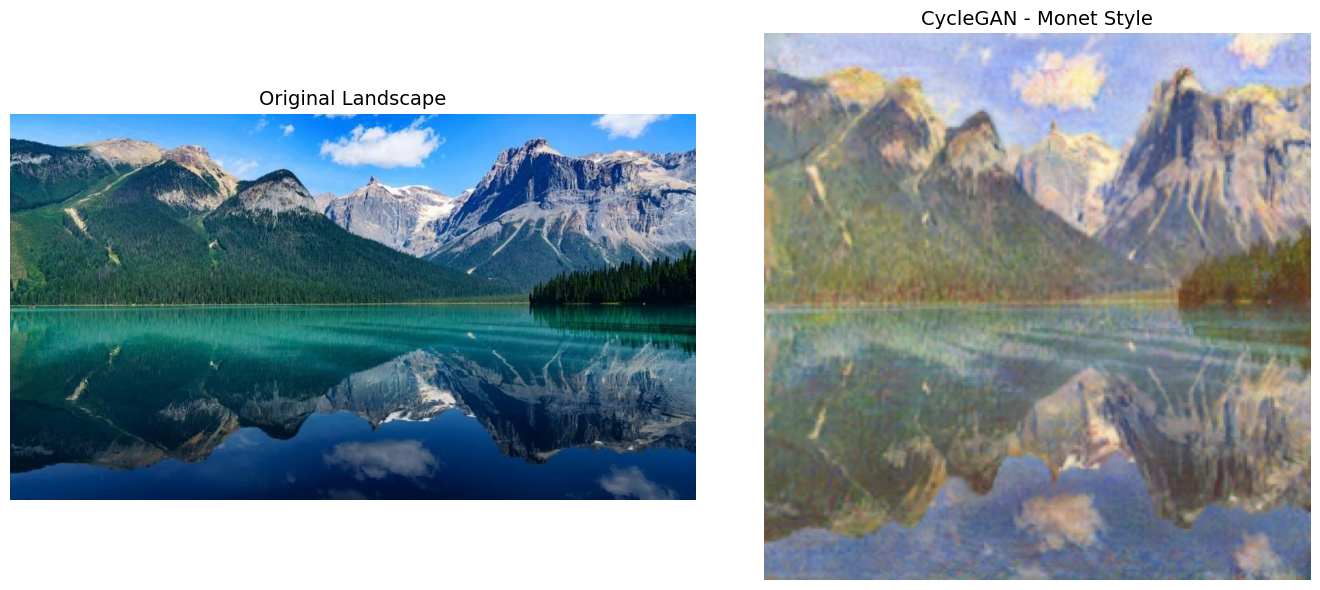

In [31]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Original Landscape", fontsize=14)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cyclegan_output)
plt.title("CycleGAN - Monet Style", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()

# Method 2: Neural Style Transfer

## 14. Neural Style Transfer

Neural Style Transfer combines:

- **Content:** the original landscape photograph.
- **Style:** the selected painting.

A pretrained VGG19 network is used only as a feature extractor. The VGG19 weights are not trained or changed.

## 15. Load the Pretrained VGG19 Network

Earlier VGG19 layers capture lower-level visual patterns such as edges and textures, while deeper layers capture more complex visual structures.

The network is used to calculate content and style representations.

In [32]:
import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

vgg = models.vgg19(
    weights=models.VGG19_Weights.DEFAULT
).features.to(device)

vgg.eval()

for parameter in vgg.parameters():
    parameter.requires_grad = False

print("VGG19 loaded successfully.")

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130
Using device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 78.8MB/s]


VGG19 loaded successfully.


## 16. Load and Preprocess the Images

Both images are resized to 512 × 512 pixels.

VGG19 was trained using ImageNet normalization, so normalization is applied inside the feature-extraction function below.

In [33]:
image_size = 512

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

content = transform(
    content_image
).unsqueeze(0).to(device)

style = transform(
    style_image
).unsqueeze(0).to(device)

# ImageNet normalization used by pretrained VGG19
mean = torch.tensor(
    [0.485, 0.456, 0.406],
    device=device
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225],
    device=device
).view(1, 3, 1, 1)

print("Content tensor shape:", content.shape)
print("Style tensor shape:", style.shape)

Content tensor shape: torch.Size([1, 3, 512, 512])
Style tensor shape: torch.Size([1, 3, 512, 512])


## 17. Select Content and Style Layers

The VGG19 feature layers are selected using their feature-network indices.

- `21` is used as the content layer.
- `0`, `5`, `10`, `19`, and `28` are used as style layers.

The content layer helps preserve structure, while multiple style layers capture different levels of texture and visual patterns.

In [34]:
content_layers = ["21"]

style_layers = [
    "0",
    "5",
    "10",
    "19",
    "28"
]

print("Content layers:", content_layers)
print("Style layers:", style_layers)

Content layers: ['21']
Style layers: ['0', '5', '10', '19', '28']


## 18. Extract Content and Style Features

The images are passed through VGG19.

For the content image, the selected content feature is stored.

For the painting, the selected style features are stored.

In [35]:
def normalize_for_vgg(image):
    return (image - mean) / std


def get_features(image, model, layers):
    features = {}

    x = normalize_for_vgg(image)

    for name, layer in model._modules.items():
        x = layer(x)

        if name in layers:
            features[name] = x

    return features


content_features = get_features(
    content,
    vgg,
    content_layers
)

style_features = get_features(
    style,
    vgg,
    style_layers
)

print(
    "Content features:",
    list(content_features.keys())
)

print(
    "Style features:",
    list(style_features.keys())
)

Content features: ['21']
Style features: ['0', '5', '10', '19', '28']


## 19. Calculate the Gram Matrix

The Gram Matrix represents relationships between feature maps.

In Neural Style Transfer, Gram Matrices are used to represent style-related information such as textures and patterns.

In [36]:
def gram_matrix(tensor):
    batch_size, channels, height, width = tensor.size()

    features = tensor.view(
        channels,
        height * width
    )

    gram = torch.mm(
        features,
        features.t()
    )

    return gram / (
        channels * height * width
    )


style_grams = {}

for layer in style_layers:
    style_grams[layer] = gram_matrix(
        style_features[layer]
    )

print("Style Gram Matrices calculated.")

for layer, matrix in style_grams.items():
    print(
        f"Layer {layer}: {tuple(matrix.shape)}"
    )

Style Gram Matrices calculated.
Layer 0: (64, 64)
Layer 5: (128, 128)
Layer 10: (256, 256)
Layer 19: (512, 512)
Layer 28: (512, 512)


## 20. Create the Target Image

The target image starts as a copy of the original landscape.

During optimization, only the target image is changed. VGG19 remains frozen.

In [37]:
target = content.clone().detach().requires_grad_(True)

print("Target image created.")
print("Target shape:", target.shape)

Target image created.
Target shape: torch.Size([1, 3, 512, 512])


## 21. Define Content Loss, Style Loss, and Optimizer

The total loss combines:

**Total Loss = Content Weight × Content Loss + Style Weight × Style Loss**

The optimizer updates the target image so that its content features become similar to the landscape and its style features become similar to the painting.

In [38]:
content_weight = 1

style_weight = 1_000_000

optimizer = torch.optim.Adam(
    [target],
    lr=0.02
)

print("Content weight:", content_weight)
print("Style weight:", style_weight)
print("Optimizer: Adam")

Content weight: 1
Style weight: 1000000
Optimizer: Adam


## 22. Perform Neural Style Transfer

At every iteration:

1. Extract VGG19 features from the target image.
2. Calculate content loss.
3. Calculate style loss using Gram Matrices.
4. Combine the losses.
5. Backpropagate the loss.
6. Update the target image.
7. Keep pixel values in the valid range.

A moderate number of steps is used so that the experiment remains practical in Google Colab.

In [39]:
num_steps = 300

print("Starting Neural Style Transfer...")
print("Total steps:", num_steps)

for step in range(1, num_steps + 1):

    target_features = get_features(
        target,
        vgg,
        content_layers + style_layers
    )

    # Content loss
    content_loss = torch.mean(
        (
            target_features["21"]
            - content_features["21"]
        ) ** 2
    )

    # Style loss
    style_loss = 0.0

    for layer in style_layers:

        target_gram = gram_matrix(
            target_features[layer]
        )

        style_loss += torch.mean(
            (
                target_gram
                - style_grams[layer]
            ) ** 2
        )

    # Total loss
    total_loss = (
        content_weight * content_loss
        + style_weight * style_loss
    )

    optimizer.zero_grad()

    total_loss.backward()

    optimizer.step()

    # Keep image values between 0 and 1
    with torch.no_grad():
        target.clamp_(0, 1)

    if step % 50 == 0:
        print(
            f"Step {step}/{num_steps} | "
            f"Content Loss: {content_loss.item():.6f} | "
            f"Style Loss: {style_loss.item():.6f} | "
            f"Total Loss: {total_loss.item():.6f}"
        )

print("Neural Style Transfer completed.")

Starting Neural Style Transfer...
Total steps: 300
Step 50/300 | Content Loss: 1.771908 | Style Loss: 0.000003 | Total Loss: 4.795363
Step 100/300 | Content Loss: 1.441021 | Style Loss: 0.000002 | Total Loss: 3.545479
Step 150/300 | Content Loss: 1.370921 | Style Loss: 0.000002 | Total Loss: 3.013784
Step 200/300 | Content Loss: 1.307493 | Style Loss: 0.000001 | Total Loss: 2.702316
Step 250/300 | Content Loss: 1.213028 | Style Loss: 0.000002 | Total Loss: 2.762265
Step 300/300 | Content Loss: 1.230784 | Style Loss: 0.000001 | Total Loss: 2.372107
Neural Style Transfer completed.


## 23. Display the Neural Style Transfer Output

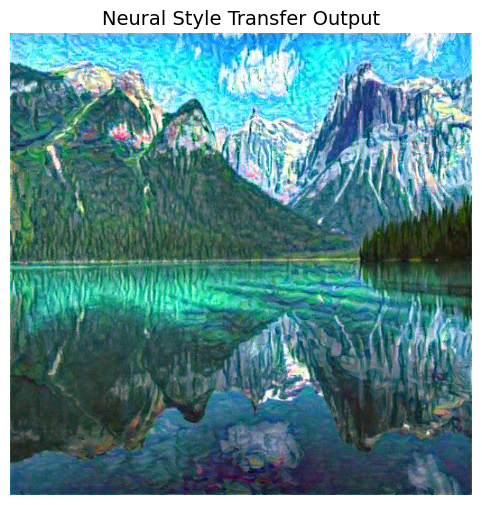

In [40]:
def tensor_to_pil(tensor):

    image = (
        tensor
        .detach()
        .cpu()
        .squeeze(0)
    )

    image = image.permute(
        1, 2, 0
    ).numpy()

    image = np.clip(
        image,
        0,
        1
    )

    image = (
        image * 255
    ).astype("uint8")

    return Image.fromarray(image)


import numpy as np

nst_output = tensor_to_pil(target)

plt.figure(figsize=(8, 6))

plt.imshow(nst_output)

plt.title(
    "Neural Style Transfer Output",
    fontsize=14
)

plt.axis("off")

plt.show()

## 24. Save the Neural Style Transfer Output

The generated image is saved so that it can be used in the final comparison and submission.

In [41]:
nst_output_path = "/content/neural_style_transfer_output.jpg"

nst_output.save(
    nst_output_path,
    quality=95
)

print("Saved:", nst_output_path)

Saved: /content/neural_style_transfer_output.jpg


# Final Comparison

## 25. Compare the Three Images

The assignment requires the following three images to be shown side by side:

1. Original image
2. CycleGAN output
3. Neural Style Transfer output

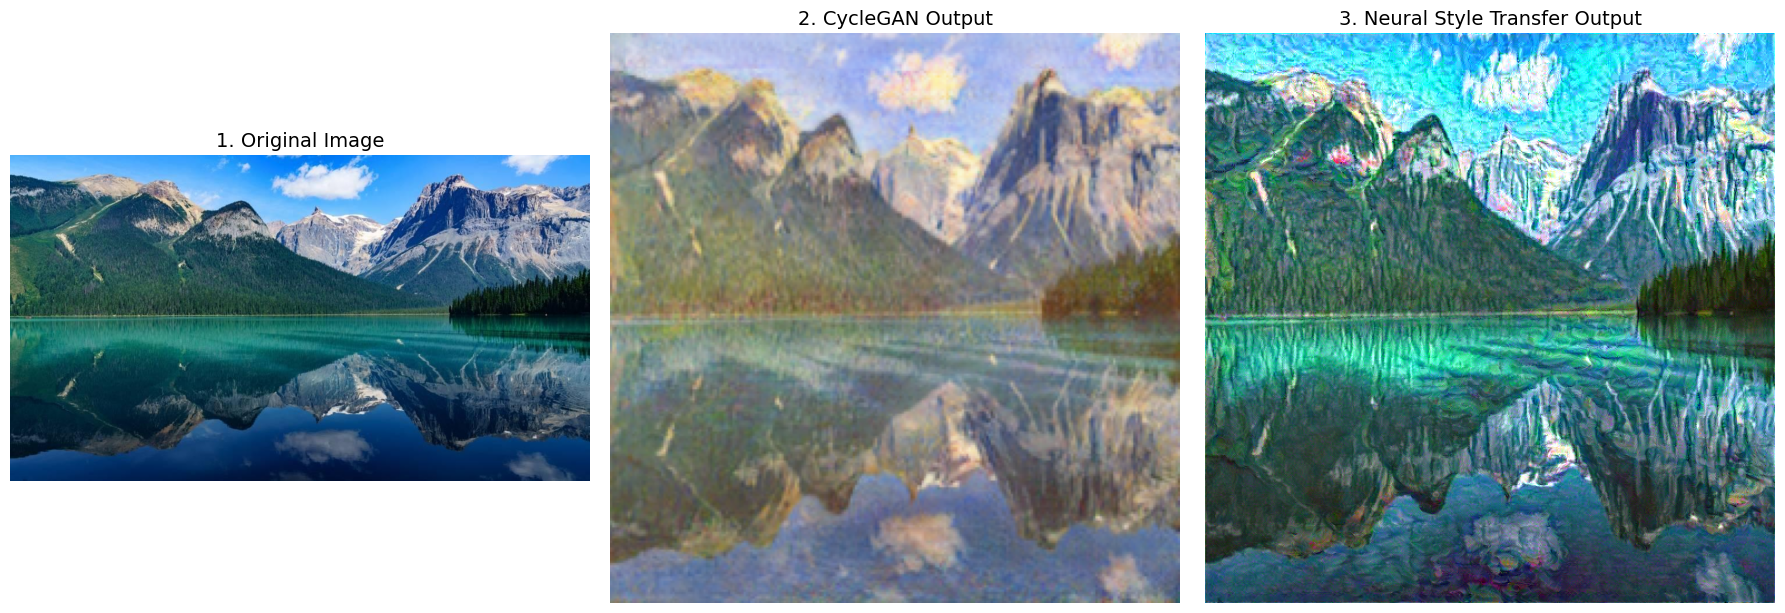

In [42]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)

plt.imshow(content_image)

plt.title(
    "1. Original Image",
    fontsize=14
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(cyclegan_output)

plt.title(
    "2. CycleGAN Output",
    fontsize=14
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(nst_output)

plt.title(
    "3. Neural Style Transfer Output",
    fontsize=14
)

plt.axis("off")


plt.tight_layout()

plt.show()

## 26. Save the Final Comparison

The comparison image is saved at high resolution for submission.

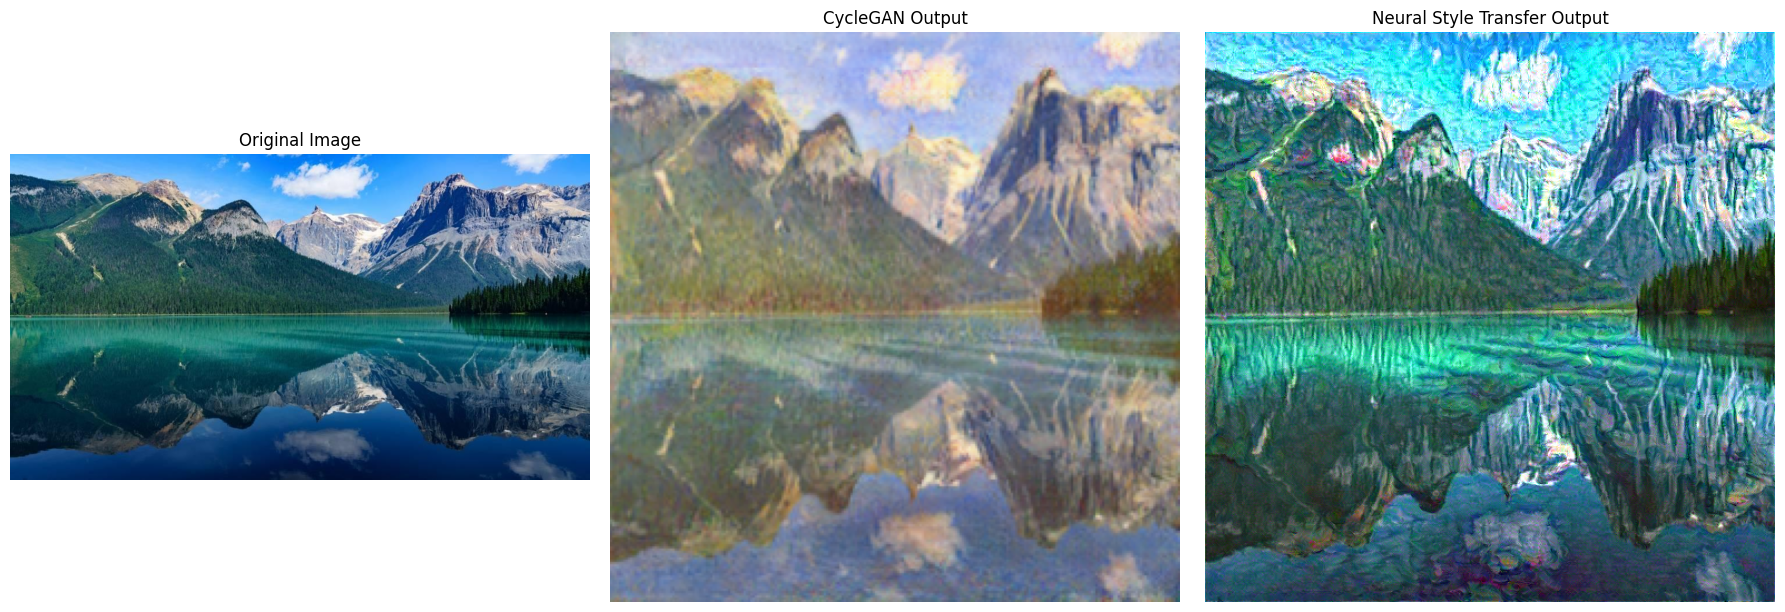

Comparison saved successfully:
/content/Assignment_6_Comparison.png


In [43]:
comparison_path = "/content/Assignment_6_Comparison.png"

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)

plt.imshow(content_image)

plt.title(
    "Original Image"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(cyclegan_output)

plt.title(
    "CycleGAN Output"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(nst_output)

plt.title(
    "Neural Style Transfer Output"
)

plt.axis("off")


plt.tight_layout()

plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Comparison saved successfully:")
print(comparison_path)

## 27. Method Comparison

| Feature | CycleGAN | Neural Style Transfer |
|---|---|---|
| Main purpose | Image-to-image/domain translation | Content + artistic style transfer |
| Model used | Pretrained CycleGAN | Pretrained VGG19 |
| Content input | Original landscape | Original landscape |
| Style source | Learned Monet domain | Selected painting |
| Training in this assignment | No additional training | No VGG19 training |
| Main concept | Adversarial translation + cycle consistency during training | Content loss + style loss |
| Style control | Determined by the pretrained model | Painting can be changed directly |

## 28. Written Comparison

### Content Preservation

The CycleGAN output preserved the main content and structure of the original landscape more clearly because the major objects, composition, and overall landscape structure remained recognizable while the visual appearance was changed.

### Strength of Style Transformation

The Neural Style Transfer output showed the stronger visible style transformation because it applied the colors, textures, brush patterns, and artistic characteristics of the selected painting more directly to the landscape.

### Differences Between the Outputs

The CycleGAN output mainly shows a Monet-like domain transformation, while the Neural Style Transfer output applies visual characteristics such as colors, textures, and patterns from the selected painting. In my results, CycleGAN produced a more consistent Monet-like appearance, while Neural Style Transfer produced a more noticeable artistic effect based on the selected style image.

### Cycle Consistency

CycleGAN uses cycle consistency during training. An image translated from one domain to another is translated back, and the model is encouraged to reconstruct an image similar to the original. This helps constrain the image translation and retain meaningful information.

## 29. Conclusion

In this assignment, two AI-based style transfer approaches were applied to the same landscape image.

CycleGAN used a pretrained Monet-style model for image-to-image translation. Neural Style Transfer used VGG19 feature representations to combine the content of the landscape with the visual style of a selected painting.

The side-by-side comparison demonstrates that the two methods use different approaches to artistic image transformation.